# 🩺 Health Condition Prediction

## Notebook 01 – Data Understanding

---

### Business Problem

A healthcare company collects lifestyle and physiological information from users, such as sleep duration, diet type, physical activity, BMI, heart rate, and other health-related metrics.

The objective is to build a machine learning model capable of predicting an individual's health condition. Early prediction can help healthcare providers identify at-risk individuals and recommend preventive interventions.

---

### Objectives

In this notebook, we will:

- Load the dataset
- Understand its structure
- Explore the available features
- Identify the target variable
- Check data types
- Identify missing values
- Check duplicate records
- Create a data dictionary
- Record initial observations

---

### Expected Output

At the end of this notebook, we should have a complete understanding of the dataset before performing any preprocessing or exploratory data analysis.

# Objectives

The purpose of this notebook is to understand the dataset before performing any preprocessing or exploratory analysis.

This notebook covers:

- Dataset overview
- Feature identification
- Data types
- Dataset dimensions
- Missing values
- Duplicate rows
- Data dictionary
- Numerical summary
- Categorical summary
- Target distribution
- Initial observations

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# ==========================================================
# Project Setup
# ==========================================================

import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.data.loader import (
    load_train_data,
    load_test_data
)

from src.profiling.profiler import DataProfiler

In [4]:
train = load_train_data()

test = load_test_data()

df = train.copy()

profiler = DataProfiler(df)

In [5]:
profiler.overview()

DATASET OVERVIEW
Rows             : 690,088
Columns          : 15
Memory Usage     : 324.36 MB
Duplicate Rows   : 0
Missing Values   : 449496


In [6]:
display(profiler.shape())

,Metric,Value
0,Rows,690088
1,Columns,15


In [7]:
display(

profiler.column_summary()

)

,Data Type,Missing Values,Missing (%),Unique Values,Cardinality (%)
id,int64,0,0.00,690088,100.00
health_condition,str,0,0.00,3,0.00
sleep_duration,float64,75999,11.01,701,0.10
heart_rate,float64,7833,1.14,537,0.08
bmi,float64,13898,2.01,1596,0.23
calorie_expenditure,float64,52853,7.66,2101,0.30
step_count,float64,13916,2.02,12807,1.86
exercise_duration,float64,6901,1.00,856,0.12
water_intake,float64,43477,6.30,400,0.06
diet_type,str,6901,1.00,3,0.00


In [8]:
num_cols, cat_cols = profiler.feature_lists()

print(f"Numerical Features ({len(num_cols)})")

print(num_cols)

Numerical Features (8)
['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


In [9]:
print(f"Categorical Features ({len(cat_cols)})")

print(cat_cols)

Categorical Features (7)
['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [10]:
display(

profiler.numerical_summary()

)

,count,mean,std,min,25%,50%,75%,max
id,690088.00,345043.50,199211.39,0.00,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.00,6.99,1.22,3.00,6.16,6.99,7.81,10.00
heart_rate,682255.00,75.10,8.18,50.00,69.40,75.10,80.70,107.70
bmi,676190.00,22.98,2.48,16.00,21.32,22.99,24.66,34.82
calorie_expenditure,637235.00,2226.08,347.53,1200.00,2053.00,2241.00,2456.00,3580.00
step_count,676172.00,8615.95,3929.40,1002.00,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.00,38.75,14.74,0.00,29.20,39.40,49.40,99.80
water_intake,646611.00,2.19,0.52,0.50,1.84,2.17,2.50,4.72


In [11]:
display(

profiler.categorical_summary()

)

,count,unique,top,freq
health_condition,690088,3,at-risk,592561
diet_type,683187,3,veg,231432
stress_level,607277,3,medium,261819
sleep_quality,631757,3,average,213948
physical_activity_level,653467,3,moderate,221041
smoking_alcohol,661506,3,yes,223730
gender,668715,3,male,237756


# Data Dictionary

The data dictionary documents the purpose of each feature used in the dataset. It serves as a reference throughout the project and helps ensure a common understanding of the variables before modelling.

In [12]:
descriptions = {
    "id": "Unique identifier assigned to each individual.",
    "health_condition": "Target variable representing the individual's overall health status.",
    "sleep_duration": "Average sleep duration per day (hours).",
    "heart_rate": "Average resting heart rate (beats per minute).",
    "bmi": "Body Mass Index (BMI).",
    "calorie_expenditure": "Estimated calories burned per day.",
    "step_count": "Total number of steps walked per day.",
    "exercise_duration": "Daily exercise duration (minutes).",
    "water_intake": "Average daily water intake (litres).",
    "diet_type": "Diet category followed by the individual.",
    "stress_level": "Reported stress level.",
    "sleep_quality": "Reported quality of sleep.",
    "physical_activity_level": "Overall physical activity level."
}

data_dictionary = profiler.column_summary().reset_index()
data_dictionary.rename(columns={"index": "Feature"}, inplace=True)

data_dictionary["Description"] = (
    data_dictionary["Feature"]
    .map(descriptions)
)

display(data_dictionary)

,Feature,Data Type,Missing Values,Missing (%),Unique Values,Cardinality (%),Description
0,id,int64,0,0.00,690088,100.00,Unique identifier assigned to each individual.
1,health_condition,str,0,0.00,3,0.00,Target variable representing the individual's ...
2,sleep_duration,float64,75999,11.01,701,0.10,Average sleep duration per day (hours).
3,heart_rate,float64,7833,1.14,537,0.08,Average resting heart rate (beats per minute).
4,bmi,float64,13898,2.01,1596,0.23,Body Mass Index (BMI).
5,calorie_expenditure,float64,52853,7.66,2101,0.30,Estimated calories burned per day.
6,step_count,float64,13916,2.02,12807,1.86,Total number of steps walked per day.
7,exercise_duration,float64,6901,1.00,856,0.12,Daily exercise duration (minutes).
8,water_intake,float64,43477,6.30,400,0.06,Average daily water intake (litres).
9,diet_type,str,6901,1.00,3,0.00,Diet category followed by the individual.


# Target Variable Analysis

The target variable represents the class that our machine learning model will predict.

Before building a model, it is important to understand whether the classes are balanced or imbalanced.

In [13]:
target_summary = (
    df["health_condition"]
      .value_counts()
      .rename_axis("Health Condition")
      .reset_index(name="Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(df) * 100
).round(2)

display(target_summary)

,Health Condition,Count,Percentage
0,at-risk,592561,85.87
1,unhealthy,57724,8.36
2,fit,39803,5.77


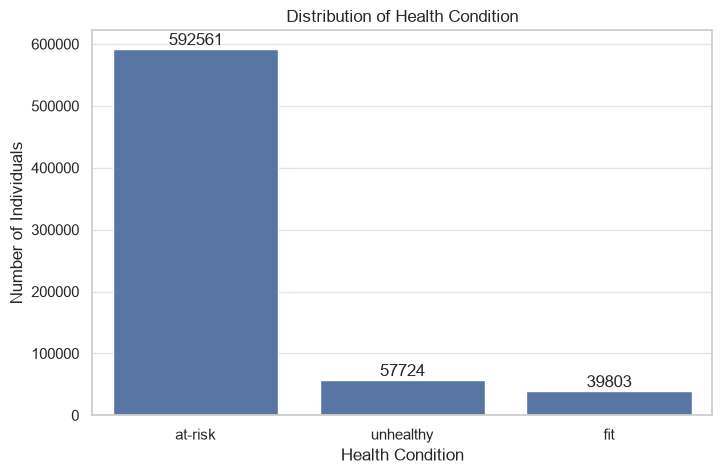

In [14]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="health_condition",
    order=df["health_condition"].value_counts().index
)

plt.title("Distribution of Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Number of Individuals")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Observations

1. The dataset contains three health-condition classes.

2. The "at-risk" category represents the majority of observations.

3. The "fit" class is the smallest category.

4. The dataset is imbalanced, indicating that evaluation metrics such as Precision, Recall, and F1-score will be more informative than accuracy alone.

# Business Insight

The presence of class imbalance suggests that the predictive model may naturally favour the majority class if trained without appropriate techniques.

During model development, strategies such as class weighting or resampling should be considered to improve the prediction of minority classes.

# Conclusion

This notebook focused on understanding the dataset before any preprocessing or modelling.

### Key Outcomes

- Dataset successfully loaded.
- Dataset structure explored.
- Feature types identified.
- Data dictionary created.
- Numerical and categorical summaries generated.
- Target variable analysed.
- Initial observations documented.

The next notebook will focus on validating data quality and preparing the dataset for exploratory data analysis.